In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import sys; sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/lib') # add library path

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from queue import PriorityQueue

from variable_print import p,ps,pst
from gym.envs.toy_text import CliffWalkingEnv
import temporal_difference as td
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## SARSA와 Q-Learning
TD method 활용한 최적정책 찾는 대표적인 방법  
>SARSA : On-policy policy evaluation   
>>행동정책, 평가정책 : $\epsilon$-greedy policy   

>Q-Learning : Off-policy policy evaluation  
>>행동정책 : $\epsilon$-greedy policy  
>>평가정책 : greedy policy  



## `CliffWalkingEnv`  

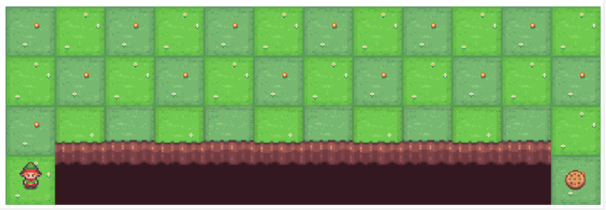

In [5]:
import gymnasium as gym

cliff_env = CliffWalkingEnv(render_mode="ansi")
cliff_env_q = CliffWalkingEnv(render_mode="ansi")

## `CliffWalkingEnv` 돌아보기

`CliffWalkingEnv`: Grid Environment 임  
1. 상태공간 $\cal{S}$: 12 x 4 격자 공간, 48 state $s$ 존재  
2. 행동 공간 $\cal{A}$: state $s$에 `'상','우','하','좌'`  
3. 초기상태 $s_0$은 항상 좌측 하단 셀  
종결상태는 가장 오른쪽 하단   
절벽상태 $c$는 초기상태와 종결상태를 제외한 모든 최하단 셀들   
4. 보상함수는 매 이동마다 `-1`  
절벽 $c$ 에 도달할 때마다 `-100`  
5. 절벽상태 $c$ 에 도달하면 다시 초기상태 $s_0$로 돌아감  

In [6]:
cliff_env.reset()
print(cliff_env.render()[0]) # ['o o ... o o\no o ... C T\n\n']

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




## SARSA, Q-Learning Agent 초기화
* gamma=0.9
* lr=1e-1
* epsilon=0.1

In [7]:
cliff_env.nS, cliff_env.nA  #(48, 4)

(np.int64(48), 4)

In [8]:
sarsa_agent = td.SARSA(gamma=0.9,
                    lr=1e-1,
                    num_states=cliff_env.nS,
                    num_actions=cliff_env.nA,
                    epsilon=0.1)

q_agent = td.QLearner(gamma=0.9,
                   lr=1e-1,
                   num_states=cliff_env.nS,
                   num_actions=cliff_env.nA,
                   epsilon=0.1)

## Agent Training


In [9]:
def run_sarsa(agent, env):
    env.reset()                                          # s <- random state
    reward_sum = 0
    while True:                                          # Episode 시행
        state = env.s                                    # s : random
        action = agent.get_action(state)                 # a <- epsilon greedy
        next_state, reward, done, info,_ = env.step(action)# s' <- step(a)
        next_action = sarsa_agent.get_action(next_state) # a' <- epsilon greedy
        agent.update_sample(state=state,
                            action=action,
                            reward=reward,
                            next_state=next_state,       ##
                            next_action=next_action,     ##
                            done=done)
        reward_sum += reward                             # epi. 보상의 합
        if done: break
    return reward_sum

def run_qlearning(agent, env):
    env.reset()                                           # s <- random state
    reward_sum = 0
    while True:                                           # Episode 시행
        state = env.s                                     # s : random
        action = agent.get_action(state)                  # a <- epsilon greedy
        next_state, reward, done, info,_ = env.step(action) # s' <- step(a)
        agent.update_sample(state=state,
                            action=action,
                            reward=reward,
                            next_state=next_state,        ##
                            done=done)
        reward_sum += reward
        if done: break
    return reward_sum

In [10]:
%%time
num_eps = 1500              # 반복 시행할 Epi.
sarsa_rewards = []          # Epi.별 보상 합
qlearning_rewards = []      #

q_agent.reset_values()      # v, q <- 0
q_agent.reset_policy()      # _policy_q <- 0 # 정책개선 하지 않음
sarsa_agent.reset_values()  # v, q <- 0
sarsa_agent.reset_policy()  # _policy_q <- 0

for i in range(num_eps):
    sarsa_reward_sum = run_sarsa(sarsa_agent, cliff_env)    # Training 1-Epi.
    qlearning_reward_sum = run_qlearning(q_agent, cliff_env_q)

    sarsa_rewards.append(sarsa_reward_sum)                  # Epi. 보상 합 저장
    qlearning_rewards.append(qlearning_reward_sum)
# Wall time: 14.8 s

CPU times: user 12.6 s, sys: 67.1 ms, total: 12.6 s
Wall time: 13 s


Wall time: 14.8 s


### 결과 시각화

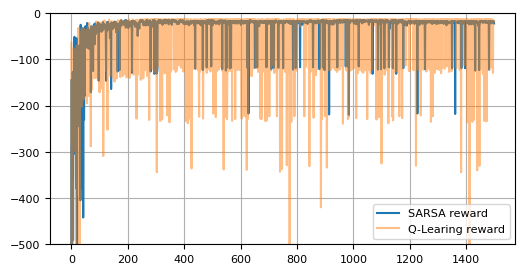

In [11]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(sarsa_rewards, label='SARSA reward')
ax.plot(qlearning_rewards, label='Q-Learing reward', alpha=0.5)
ax.grid()
ax.legend()
plt.ylim(-500,0)
plt.show()

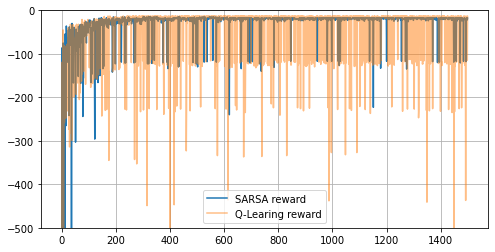

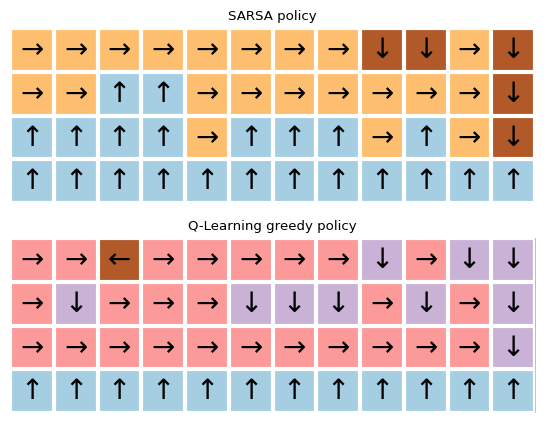

In [12]:
fig, ax = plt.subplots(2,1, figsize=(10, 5))
visualize_policy(ax[0], sarsa_agent.q, cliff_env.shape[0], cliff_env.shape[1])
_ = ax[0].set_title("SARSA policy")

visualize_policy(ax[1], q_agent.q, cliff_env_q.shape[0], cliff_env.shape[1])
_ = ax[1].set_title("Q-Learning greedy policy")

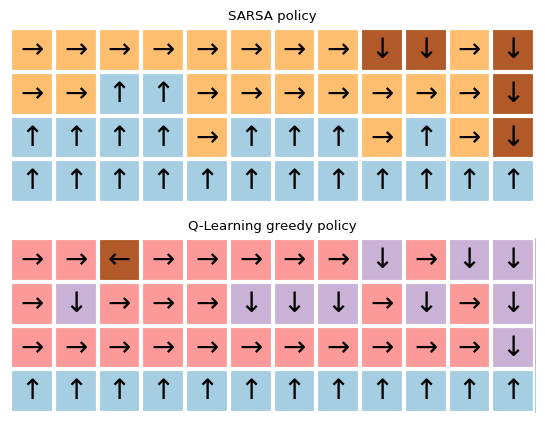

## 실습과제 : 성능개선    
### **역방향 경로가 나오지 않도록 개선해 보자**  
### $\epsilon$-greedy scheduling을 적용해 보자  
### num_eps를 수정해 보자  


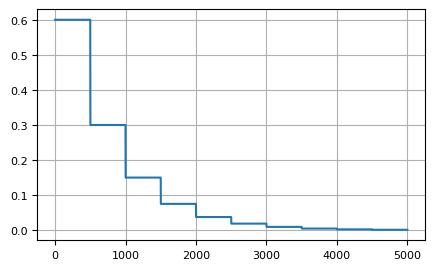

In [13]:
num_eps = 5000              # 반복 시행할 Epi.
decay_step = 500
epsi_start = 0.6 # 0.5
epsi_decay = 0.5 # 0.3

epsilon = []
for i in range(num_eps):
    epsilon.append(epsi_start * epsi_decay**(i//decay_step))

plt.figure(figsize=(5,3))
plt.plot(epsilon)
plt.grid()
plt.show()

## 과제 1 : Epsilon=0


In [14]:
cliff_env.close()
cliff_env_q.close()
cliff_env = CliffWalkingEnv(render_mode="ansi")
cliff_env_q = CliffWalkingEnv(render_mode="ansi")

In [15]:
# num_eps = 5000              # 반복 시행할 Epi.
# decay_step = 500
# epsi_start = 0.5 # 0.5
# epsi_decay = 0.5 # 0.3
sarsa_agent.epsilon = q_agent.epsilon = epsi_start

In [16]:
%%time
sarsa_rewards = []          # Epi.별 보상 합
qlearning_rewards = []      #

q_agent.reset_values()      # v, q <- 0
sarsa_agent.reset_values()  # v, q <- 0

for i in range(num_eps):
    epsi_new = epsi_start * epsi_decay**(i//decay_step)
    sarsa_agent.epsilon = q_agent.epsilon = epsi_new

    sarsa_reward_sum = run_sarsa(sarsa_agent, cliff_env)    # Training 1-Epi.
    qlearning_reward_sum = run_qlearning(q_agent, cliff_env_q)

    sarsa_rewards.append(sarsa_reward_sum)                  # Epi. 보상 합 저장
    qlearning_rewards.append(qlearning_reward_sum)

    if (i%decay_step)==0 :
        print(f"Epi.[{i}], epsilon:{epsi_new}")

# Wall time: 1min 7s

Epi.[0], epsilon:0.6
Epi.[500], epsilon:0.3
Epi.[1000], epsilon:0.15
Epi.[1500], epsilon:0.075
Epi.[2000], epsilon:0.0375
Epi.[2500], epsilon:0.01875
Epi.[3000], epsilon:0.009375
Epi.[3500], epsilon:0.0046875
Epi.[4000], epsilon:0.00234375
Epi.[4500], epsilon:0.001171875
CPU times: user 6min 58s, sys: 1.86 s, total: 7min
Wall time: 7min 4s


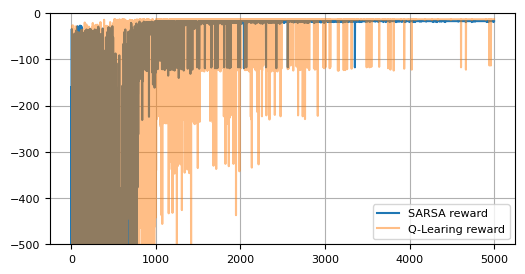

In [17]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(sarsa_rewards, label='SARSA reward')
ax.plot(qlearning_rewards, label='Q-Learing reward', alpha=0.5)
ax.grid()
ax.legend()
plt.ylim(-500,0)
plt.show()

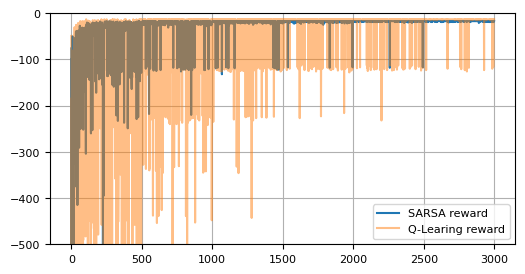

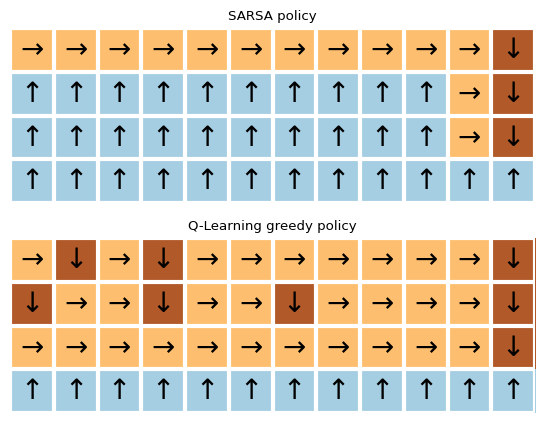

In [18]:
fig, ax = plt.subplots(2,1, figsize=(10, 5))
visualize_policy(ax[0], sarsa_agent.q, cliff_env.shape[0], cliff_env.shape[1])
_ = ax[0].set_title("SARSA policy")

visualize_policy(ax[1], q_agent.q, cliff_env.shape[0], cliff_env.shape[1])
_ = ax[1].set_title("Q-Learning greedy policy")

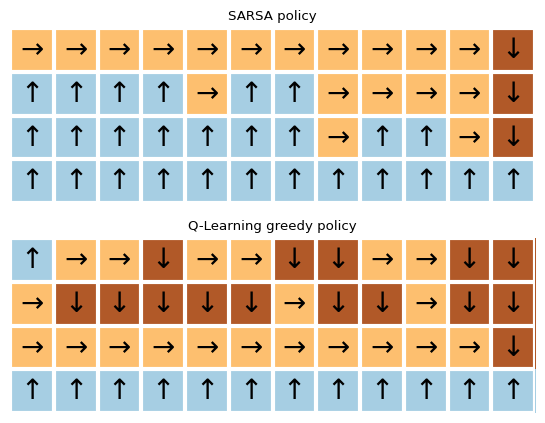

## 실습과제 : FrozenLake  
https://www.gymlibrary.dev/environments/toy_text/frozen_lake/   
### **FrozenLake 환경을 사용하여**  
### SARSA 및 Q-Learner Agent를 만들고, 학습 시켜 보자   
>어떻게 성능을 확인하고 비교할까?

## FrozenLake Env.

In [20]:
import gym.envs.toy_text.frozen_lake as fl
env = fl.FrozenLakeEnv(map_name="4x4",render_mode="ansi") # 8x8
env.reset()
print(env.render()[0])


SFFF
FHFH
FFFH
HFFG



In [22]:
num_states=16
sarsa_agent = td.SARSA(gamma=0.9,
                    lr=1e-1,
                    num_states=num_states,#env.nS,
                    num_actions=4,#env.nA,
                    epsilon=0.5)  # 뒤에서 다시 설정

q_agent = td.QLearner(gamma=0.9,
                   lr=1e-1,
                   num_states=num_states,#env.nS,
                   num_actions=4,#env.nA,
                   epsilon=0.5)   # 뒤에서 다시 설정

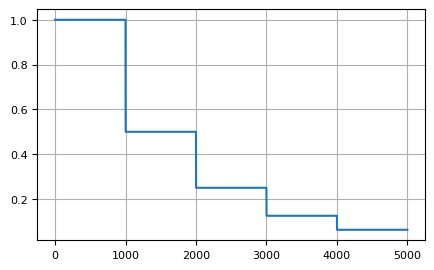

In [23]:
num_eps = 5000             # 반복 시행할 Epi.
epsi_start = 1.0
epsi_decay = .5
decay_step = 1000
epsilon = []
for i in range(num_eps):
    epsilon.append(epsi_start * epsi_decay**(i//decay_step))

plt.figure(figsize=(5,3))
plt.plot(epsilon)
plt.grid()
plt.show()

Epi.[1000], epsilon:0.50000, sarsa_rewards:0.0, qlearning_rewards:0.0


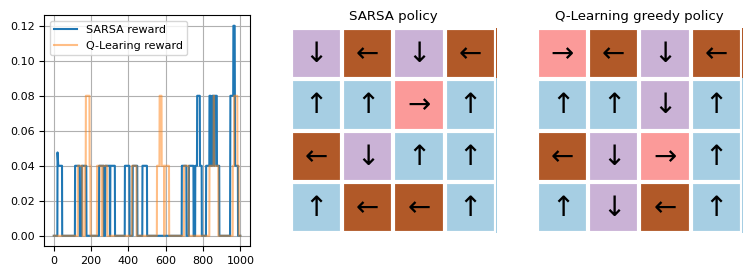

Epi.[2000], epsilon:0.25000, sarsa_rewards:0.04, qlearning_rewards:0.0


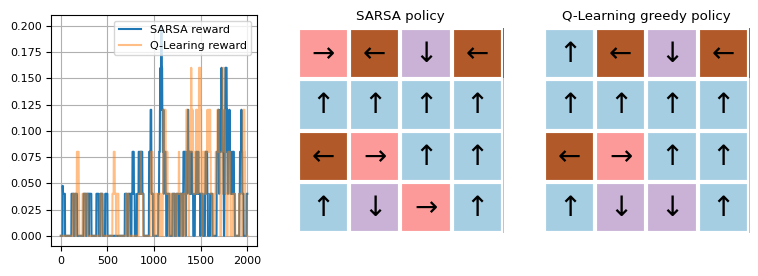

Epi.[3000], epsilon:0.12500, sarsa_rewards:0.04, qlearning_rewards:0.24


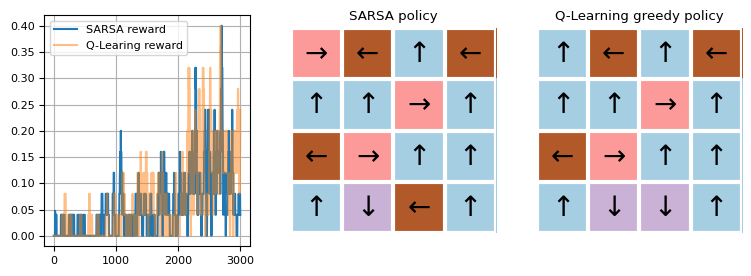

Epi.[4000], epsilon:0.06250, sarsa_rewards:0.16, qlearning_rewards:0.24


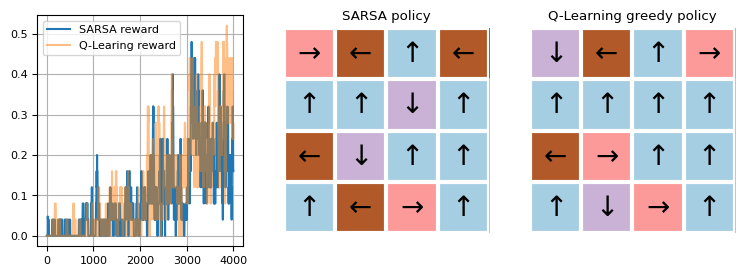

Epi.[5000], epsilon:0.03125, sarsa_rewards:0.24, qlearning_rewards:0.36


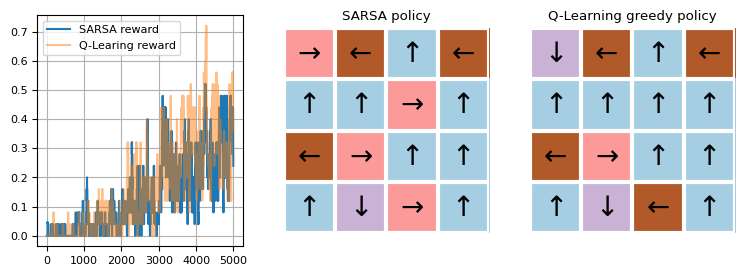

In [24]:
#%%time
sarsa_rewards = []          # Epi.별 보상 합
qlearning_rewards = []      #
s_reward_mean = []
q_reward_mean = []
q_agent.reset_values()      # v, q <- 0
sarsa_agent.reset_values()  # v, q <- 0

env.reset()

for i in range(1,num_eps+1):
    epsi_new = epsi_start * epsi_decay**(i//decay_step)
    sarsa_agent.epsilon = q_agent.epsilon = epsi_new

    sarsa_reward_sum = run_sarsa(sarsa_agent, env)    # Training 1-Epi.
    qlearning_reward_sum = run_qlearning(q_agent, env)

    sarsa_rewards.append(sarsa_reward_sum)                  # Epi. 보상 합 저장
    qlearning_rewards.append(qlearning_reward_sum)
    s_reward_mean.append(np.array(sarsa_rewards[-25:]).mean())
    q_reward_mean.append(np.array(qlearning_rewards[-25:]).mean())
    if (i%decay_step)==0 :
        j = i//decay_step
        print(f"Epi.[{i}], epsilon:{epsi_new:0.5f}, sarsa_rewards:{s_reward_mean[-1]}, qlearning_rewards:{q_reward_mean[-1]}")
        fig, ax = plt.subplots(1,3, figsize=(9,3))
        ax[0].plot(s_reward_mean, label='SARSA reward')
        ax[0].plot(q_reward_mean, label='Q-Learing reward', alpha=0.5)
        ax[0].grid()
        ax[0].legend()

        visualize_policy(ax[1], sarsa_agent.q, env.ncol, env.ncol)
        _ = ax[1].set_title("SARSA policy")

        visualize_policy(ax[2], q_agent.q, env.ncol, env.ncol)
        _ = ax[2].set_title("Q-Learning greedy policy")
        plt.show()

Epi.[5000], epsilon:0.03125, sarsa_rewards:0.24, qlearning_rewards:0.36   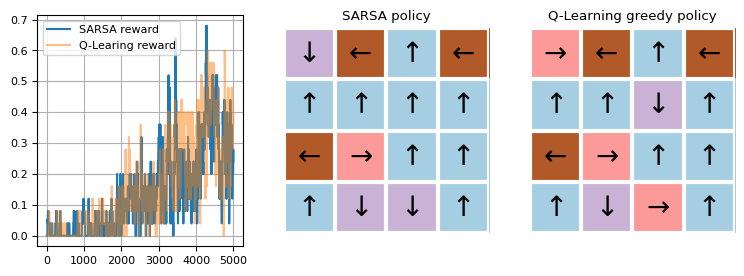

Epi.[5000], epsilon:0.01562, sarsa_rewards:0.68, qlearning_rewards:0.52  
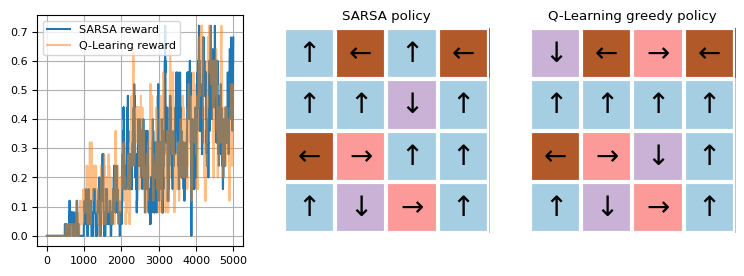


In [25]:
import gym.envs.toy_text.frozen_lake as fl
env = fl.FrozenLakeEnv(map_name="8x8",render_mode="ansi") # 8x8 4x4
env.reset()
print(env.render()[0])


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



In [26]:
num_states=64 #16
sarsa_agent = td.SARSA(gamma=0.9,
                    lr=1e-1,
                    num_states=num_states,#env.nS,
                    num_actions=4,#env.nA,
                    epsilon=0.5)  # 뒤에서 다시 설정

q_agent = td.QLearner(gamma=0.9,
                   lr=1e-1,
                   num_states=num_states,#env.nS,
                   num_actions=4,#env.nA,
                   epsilon=0.5)   # 뒤에서 다시 설정

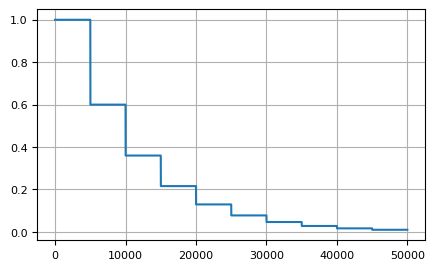

In [27]:
num_eps = 50000             # 반복 시행할 Epi.
epsi_start = 1.0
epsi_decay = .6
decay_step = 5000
epsilon = []
for i in range(num_eps):
    epsilon.append(epsi_start * epsi_decay**(i//decay_step))

plt.figure(figsize=(5,3))
plt.plot(epsilon)
plt.grid()
plt.show()

Epi.[5000], epsilon:0.60000, sarsa_rewards:0.0, qlearning_rewards:0.0


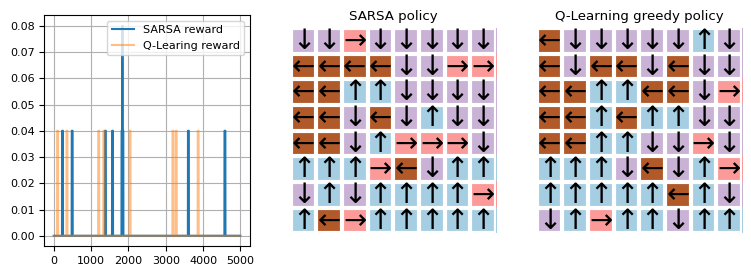

Epi.[10000], epsilon:0.36000, sarsa_rewards:0.04, qlearning_rewards:0.0


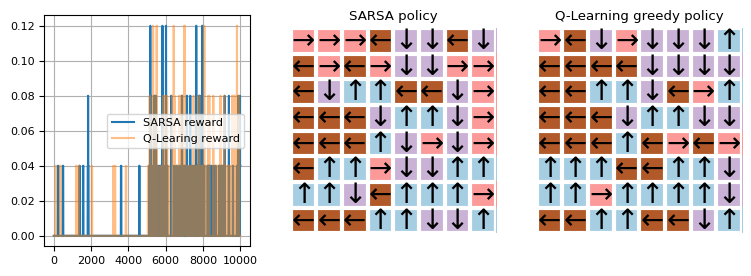

Epi.[15000], epsilon:0.21600, sarsa_rewards:0.04, qlearning_rewards:0.0


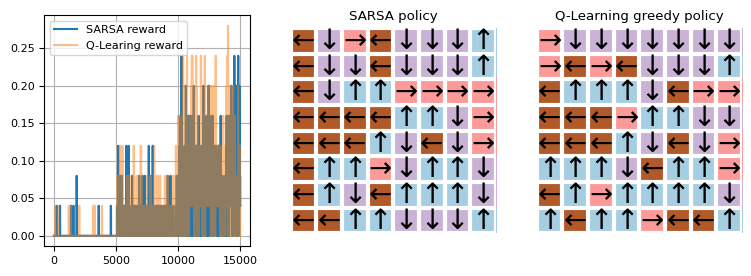

Epi.[20000], epsilon:0.12960, sarsa_rewards:0.2, qlearning_rewards:0.0


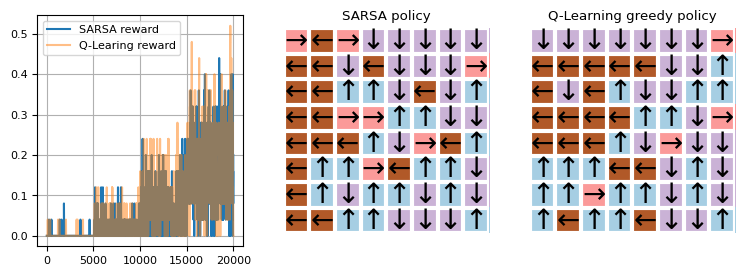

Epi.[25000], epsilon:0.07776, sarsa_rewards:0.2, qlearning_rewards:0.16


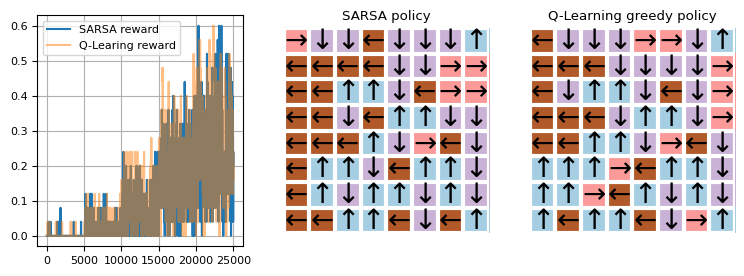

Epi.[30000], epsilon:0.04666, sarsa_rewards:0.16, qlearning_rewards:0.2


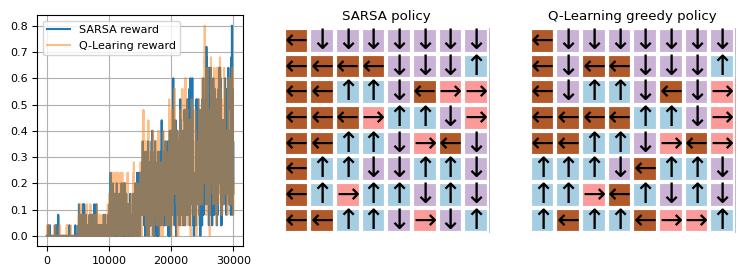

Epi.[35000], epsilon:0.02799, sarsa_rewards:0.6, qlearning_rewards:0.36


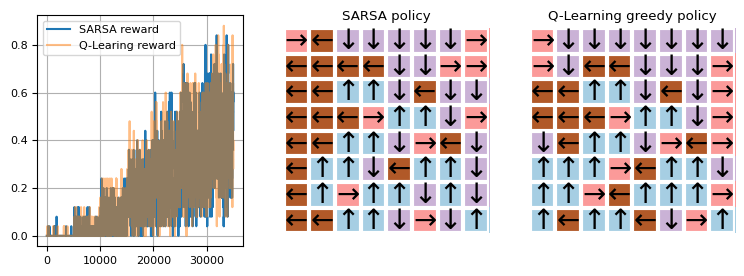

Epi.[40000], epsilon:0.01680, sarsa_rewards:0.12, qlearning_rewards:0.28


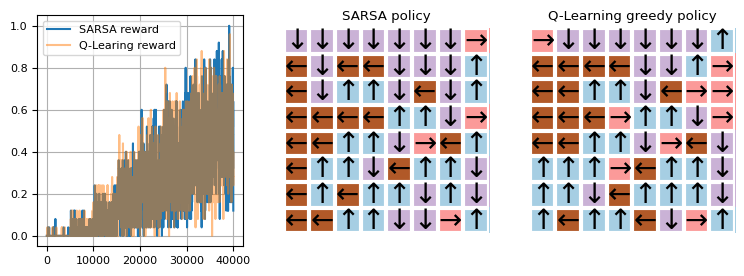

Epi.[45000], epsilon:0.01008, sarsa_rewards:0.2, qlearning_rewards:0.64


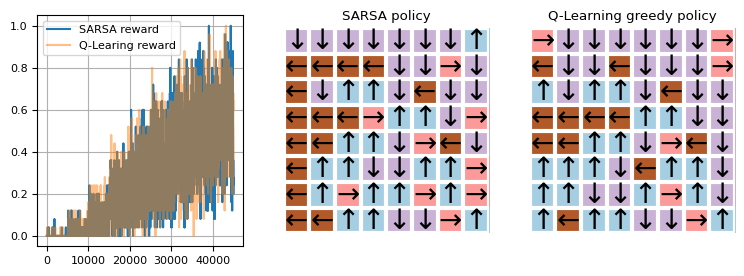

Epi.[50000], epsilon:0.00605, sarsa_rewards:0.4, qlearning_rewards:0.68


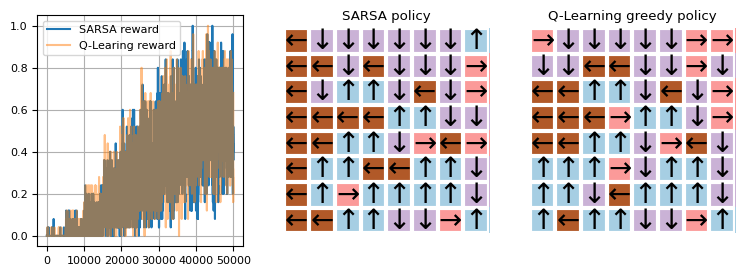

CPU times: user 5min 25s, sys: 6.24 s, total: 5min 31s
Wall time: 5min 32s


In [ ]:
%%time
sarsa_rewards = []          # Epi.별 보상 합
qlearning_rewards = []      #
s_reward_mean = []
q_reward_mean = []
q_agent.reset_values()      # v, q <- 0
sarsa_agent.reset_values()  # v, q <- 0

env.reset()

for i in range(1,num_eps+1):
    epsi_new = epsi_start * epsi_decay**(i//decay_step)
    sarsa_agent.epsilon = q_agent.epsilon = epsi_new

    sarsa_reward_sum = run_sarsa(sarsa_agent, env)    # Training 1-Epi.
    qlearning_reward_sum = run_qlearning(q_agent, env)

    sarsa_rewards.append(sarsa_reward_sum)                  # Epi. 보상 합 저장
    qlearning_rewards.append(qlearning_reward_sum)
    s_reward_mean.append(np.array(sarsa_rewards[-25:]).mean())
    q_reward_mean.append(np.array(qlearning_rewards[-25:]).mean())
    if (i%decay_step)==0 :
        j = i//decay_step
        print(f"Epi.[{i}], epsilon:{epsi_new:0.5f}, sarsa_rewards:{s_reward_mean[-1]}, qlearning_rewards:{q_reward_mean[-1]}")
        fig, ax = plt.subplots(1,3, figsize=(9,3))
        ax[0].plot(s_reward_mean, label='SARSA reward')
        ax[0].plot(q_reward_mean, label='Q-Learing reward', alpha=0.5)
        ax[0].grid()
        ax[0].legend()

        visualize_policy(ax[1], sarsa_agent.q, env.ncol, env.ncol)
        _ = ax[1].set_title("SARSA policy")

        visualize_policy(ax[2], q_agent.q, env.ncol, env.ncol)
        _ = ax[2].set_title("Q-Learning greedy policy")
        plt.show()

Epi.[50000], epsilon:0.00605, sarsa_rewards:0.68, qlearning_rewards:0.88
  
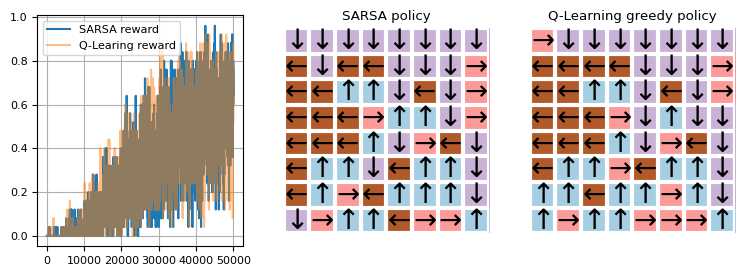  

    SFFFFFFF
    FFFFFFFF
    FFFHFFFF
    FFFFFHFF
    FFFHFFFF
    FHHFFFHF
    FHFFHFHF
    FFFHFFFG